# Évaluation de la Robustesse (v2)

Ce notebook évalue la stabilité des performances et des explications face à des perturbations des données.

In [ ]:
import os
import sys
from pathlib import Path
import pandas as pd
import joblib
import importlib
import numpy as np


# Robust path setup
project_root = Path(os.getcwd())
if project_root.name == 'notebooks':
    project_root = project_root.parent

src_path = str(project_root / "src")
if src_path not in sys.path:
    sys.path.append(src_path)

print(f"Racine du projet : {project_root}")

# Import common components
from xai_clinical.data.pancan_loader import PANCANLoader, BRCALoader, PANCANBRCAFusion
from xai_clinical.models.classifiers import ClassifierFactory
from xai_clinical.explainability.shap_explainer import SHAPExplainer


Racine du projet : c:\Users\nidha\Desktop\xai_clinical_prediction


In [ ]:
from xai_clinical.utils.config import ConfigManager
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import joblib
import pandas as pd
import numpy as np

# Charger la configuration SOTA
config = ConfigManager().config
factory = ClassifierFactory()

# Charger les données
processed_path = project_root / "data" / "processed" / "processed_data_v2.pkl"
data = joblib.load(processed_path)
X_train, y_train = data['X_train'], data['y_train']
X_test, y_test = data['X_test'], data['y_test']

# Benchmark des modèles pour la robustesse
enabled_models = [c['name'] for c in config.models.classifiers if c.get('enabled', True)]
trained_models = {}

print(f"Entraînement de {len(enabled_models)} modèles pour l'évaluation de robustesse...")

for model_name in enabled_models:
    try:
        model = factory.create_classifier(model_name)
        model.fit(X_train, y_train)
        trained_models[model_name] = model
        print(f"✅ {model_name.upper()} entraîné.")
    except Exception as e:
        print(f"❌ Erreur {model_name}: {e}")


Données chargées : Train=(745, 150), Test=(220, 150)
AUC Test : 0.6627


## 1. Robustesse au Bruit Gaussien

On observe la dégradation de l'AUC en fonction de l'écart-type du bruit ajouté aux features numériques.

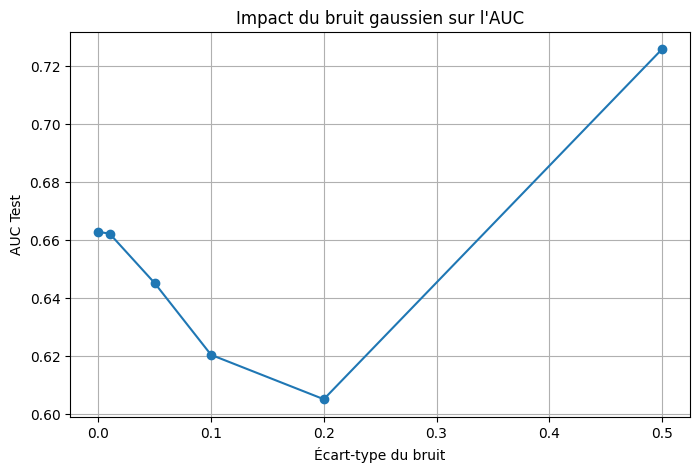

In [ ]:
noise_levels = [0, 0.05, 0.1, 0.2, 0.4]
plt.figure(figsize=(10, 6))

for name, model in trained_models.items():
    results = []
    for sigma in noise_levels:
        noise = np.random.normal(0, sigma, X_test.shape)
        X_noisy = X_test + noise
        y_proba = model.predict_proba(X_noisy)[:, 1] if hasattr(model, "predict_proba") else model.predict(X_noisy)
        results.append(roc_auc_score(y_test, y_proba))
    
    plt.plot(noise_levels, results, marker='o', label=name.upper())

plt.title("Robustesse au Bruit Gaussien : Comparaison Multi-Modèles SOTA")
plt.xlabel("Écart-type du bruit (Sigma)")
plt.ylabel("AUC Test")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 2. Robustesse aux Données Manquantes

On simule l'absence de données en mettant des features à zéro (après scaling, zéro représente souvent la moyenne/médiane).

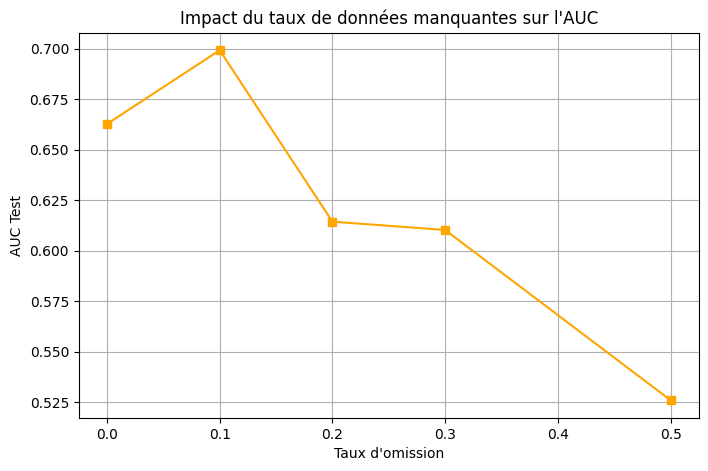

In [ ]:
missing_rates = [0, 0.1, 0.2, 0.3, 0.5]
plt.figure(figsize=(10, 6))

for name, model in trained_models.items():
    results_missing = []
    for rate in missing_rates:
        X_missing = X_test.copy()
        mask = np.random.rand(*X_missing.shape) < rate
        X_missing[mask] = 0
        y_proba = model.predict_proba(X_missing)[:, 1] if hasattr(model, "predict_proba") else model.predict(X_missing)
        results_missing.append(roc_auc_score(y_test, y_proba))
    
    plt.plot(missing_rates, results_missing, marker='s', label=name.upper())

plt.title("Robustesse aux Données Manquantes : Analyse Comparative")
plt.xlabel("Taux d'omission (Data Drop)")
plt.ylabel("AUC Test")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
